# 4 Methods for Unbalanced Data

In this notebook, we'll cover **4 different approaches to handle unbalanced data for a classification problem**. Unbalanced data can represent a significant obstacle to building an effective model, as the training procedure will tend to favour the majority class(es) over all others. This scenario often occurs in industries such as finance and health care, ... to name two examples. 

The 4 methods covered here include:

1. Oversampling the minority class
2. Undersampling the majority class
3. Synethic data
4. Class weights

## Setup

We will consider a binary classification problem for this analysis. For modelling, a Random Forest Classifier will be used. Let's import the packages required, and create our data:

In [1]:
# import packages
from typing import Dict
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata

In [2]:
# setup dataset
X, y = make_classification(
    n_samples = 10000, 
    n_features = 100, 
    n_informative = 10, 
    n_redundant = 40, 
    n_repeated = 40,
    n_classes = 2,
    weights = [0.95, 0.05],
    random_state = 42,
    return_X_y = True
)

In [3]:
# package data as a single pandas dataframe
data_df = pd.DataFrame(X, columns = [f"col{i+1}" for i in range(X.shape[1])])
data_df['label'] = y

In [4]:
# quick view of our data
data_df.head(5)

,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,...,col92,col93,col94,col95,col96,col97,col98,col99,col100,label
0,0.151922,-6.734644,5.201368,2.052704,3.423540,-10.059636,-0.251157,1.135301,0.920288,-1.678896,...,2.477597,-4.030009,2.477597,1.053095,-0.916185,3.254087,2.477597,-1.185603,-2.618730,0
1,-3.582867,-4.016538,0.950683,-2.585681,-0.966839,9.881540,-0.359277,-1.039188,-4.825315,-0.074756,...,1.138941,3.063983,1.138941,0.318454,10.248131,1.364635,1.138941,1.183645,-5.587267,0
2,-3.644924,0.694266,2.885571,-4.866489,-2.908113,7.872043,-0.041094,-6.901115,-1.261099,1.672562,...,5.550286,3.225622,5.550286,-1.067043,6.471539,-8.352142,5.550286,1.543142,-2.665041,0
3,-1.789986,-1.398615,-0.975876,-1.375485,0.320921,4.175182,-0.483935,4.160393,0.131721,2.508892,...,-1.186731,0.139009,-1.186731,1.443084,2.650743,2.316874,-1.186731,-0.227552,1.269565,0
4,2.625991,-6.222603,1.693552,0.828452,1.678526,-6.046083,0.248109,1.608832,-0.085293,-1.732843,...,1.852815,-1.537711,1.852815,-2.336922,2.217119,3.743625,1.852815,1.519871,1.017084,0


In [5]:
# define our model
model = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)

## 0) Baseline

Before trying out any techniques for the unbalanced data, let's first measure how well our model performs on the data as-is:

In [6]:
# prepare data for evaluation
X = data_df.drop('label', axis=1)
y = data_df.label

In [7]:
# perform cv 
baseline_results = cross_validate(model, X, y, cv = 5, scoring=('roc_auc','f1'), n_jobs=-1)

In [8]:
baseline_results

{'fit_time': array([0.21453214, 0.21211219, 0.21194029, 0.21146607, 0.21261692]),
 'score_time': array([0.00449896, 0.00428009, 0.00419688, 0.00418806, 0.00423336]),
 'test_roc_auc': array([0.88977224, 0.85300239, 0.86868751, 0.85944042, 0.8647359 ]),
 'test_f1': array([0.54666667, 0.52631579, 0.55128205, 0.53947368, 0.50684932])}

These results aren't the best. Let's see if we can improve on this.

## 1) Oversampling the Minority Class

In this scenario, we sample with replacement from the minority class, until the number of samples from both classes are equal. Let's build a function to take care of this operation:

In [9]:
def oversample_minority_class(data_df: pd.DataFrame, minority_class: Dict[str, int]) -> pd.DataFrame:
    """
    Function to handle an unbalanced binary dataset via minority class oversampling

    Input:
        data_df -> pandas dataframe containing the features and labels
        minority_class -> dictionary containing the label column name (key) and minority value (value)
    Output:
        pandas dataframe with equal number of samples for each class
    """
    # split the data based on the label
    label_col = list(minority_class.keys())[0]
    minority = data_df[data_df[label_col] == minority_class[label_col]].copy()
    majority = data_df[data_df[label_col] != minority_class[label_col]].copy()

    # check our classes have been processed correctly
    if minority.shape[0] > majority.shape[0]:
        msg = f"minority class not properly indicated, has {minority.shape[0]} samples while the majority class has {majority.shape[0]}"
        raise ValueError(msg)

    # sample with replacement the minority class
    sampled_minority = minority.sample(n = majority.shape[0], replace = True, random_state = 42)

    # recombine the data and return
    return pd.concat([majority, sampled_minority], axis=0).reset_index(drop=True)

In [10]:
# perform oversampling
oversampled_df = oversample_minority_class(data_df, {'label': 1})

In [11]:
# prepare data for evaluation
X = oversampled_df.drop('label', axis=1)
y = oversampled_df.label

In [12]:
# perform cv 
oversampled_results = cross_validate(model, X, y, cv = 5, scoring=('roc_auc','f1'), n_jobs=-1)

In [13]:
# examine results
oversampled_results

{'fit_time': array([0.2566731 , 0.28940797, 0.29200792, 0.25867295, 0.29049706]),
 'score_time': array([0.00513101, 0.00572181, 0.00557709, 0.00518394, 0.0057478 ]),
 'test_roc_auc': array([0.95195767, 0.94974512, 0.94917085, 0.94773484, 0.95410516]),
 'test_f1': array([0.86788155, 0.88335664, 0.86986107, 0.86623848, 0.88222098])}

These results are a good improvement over the baseline. Let's checkout the next method.

## 2) Undersampling the Majority Class

Here we'll undersample the majority class, such that we have the same number of samples for both classes. Like before, we will contain this logic in a function:

In [14]:
def undersample_majority_class(data_df: pd.DataFrame, majority_class: Dict[str, int]) -> pd.DataFrame:
    """
    Function to handle an unbalanced binary dataset via majority class undersampling

    Input:
        data_df -> pandas dataframe containing the features and labels
        majority_class -> dictionary containing the label column name (key) and majority value (value)
    Output:
        pandas dataframe with equal number of samples for each class
    """
    # split the data based on the label
    label_col = list(majority_class.keys())[0]
    minority = data_df[data_df[label_col] != majority_class[label_col]].copy()
    majority = data_df[data_df[label_col] == majority_class[label_col]].copy()

    # check our classes have been processed correctly
    if minority.shape[0] > majority.shape[0]:
        msg = f"majority class not properly indicated, has {majority.shape[0]} samples while the minority class has {minority.shape[0]}"
        raise ValueError(msg)

    # sample without replacement the majority class
    sampled_majority = majority.sample(n = minority.shape[0], replace = False, random_state = 42)

    # recombine the data and return
    return pd.concat([minority, sampled_majority], axis=0).reset_index(drop=True)

In [15]:
# perform undersampling
undersampled_df = undersample_majority_class(data_df, {'label': 0})

In [16]:
# prepare data for evaluation
X = undersampled_df.drop('label', axis=1)
y = undersampled_df.label

In [17]:
# perform cv 
undersampled_results = cross_validate(model, X, y, cv = 5, scoring=('roc_auc','f1'), n_jobs=-1)

In [18]:
# examine results
undersampled_results

{'fit_time': array([0.01984072, 0.02300906, 0.01970983, 0.02220488, 0.02111673]),
 'score_time': array([0.0028131 , 0.00327182, 0.00285602, 0.003021  , 0.00290012]),
 'test_roc_auc': array([0.91036108, 0.89104452, 0.86457369, 0.90409446, 0.91343867]),
 'test_f1': array([0.85581395, 0.82178218, 0.75621891, 0.84729064, 0.79792746])}

These results are not as good as what we saw with the over sampling technique. This is not too surprising since here we are leaving out quite a lot of data from the training procedure.

## 3) Synthetic Data

With this approach, we will model the minority class in order to generate synthetic samples to augment our dataset: 

In [19]:
def synthetic_data(data_df: pd.DataFrame, minority_class: Dict[str, int]) -> pd.DataFrame:
    """
    Function to handle an unbalanced binary dataset via sythetic data generation

    Input:
        data_df -> pandas dataframe containing the features and labels
        minority_class -> dictionary containing the label column name (key) and minority value (value)
    Output:
        pandas dataframe with equal number of samples for each class
    """
    # split the data based on the label
    label_col = list(minority_class.keys())[0]
    minority = data_df[data_df[label_col] == minority_class[label_col]].copy()
    majority = data_df[data_df[label_col] != minority_class[label_col]].copy()

    # check our classes have been processed correctly
    if minority.shape[0] > majority.shape[0]:
        msg = f"minority class not properly indicated, has {minority.shape[0]} samples while the majority class has {majority.shape[0]}"
        raise ValueError(msg)

    # generate synethic samples
    X_minority = minority.drop('label', axis=1)
    metadata = Metadata.detect_from_dataframe(X_minority)
    synthesizer = GaussianCopulaSynthesizer(metadata)
    synthesizer.fit(X_minority)
    synthetic = synthesizer.sample(num_rows=(data_df.shape[0]-2*X_minority.shape[0]))
    synthetic['label'] = 1

    # recombine the data and return
    return pd.concat([majority, minority, synthetic], axis=0).reset_index(drop=True)

In [20]:
synthetic_df = synthetic_data(data_df, {'label': 1})

/opt/homebrew/Caskroom/miniconda/base/envs/test/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/var/folders/y2/43c18q6n0634sn9yc_6q0z380000gp/T/ipykernel_34167/3939932431.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  synthetic['label'] = 1


In [21]:
# prepare data for evaluation
X = synthetic_df.drop('label', axis=1)
y = synthetic_df.label

In [22]:
# perform cv 
synthetic_results = cross_validate(model, X, y, cv = 5, scoring=('roc_auc','f1'), n_jobs=-1)

In [23]:
synthetic_results

{'fit_time': array([0.27563596, 0.39633083, 0.39413691, 0.39300394, 0.39492869]),
 'score_time': array([0.00450015, 0.00531197, 0.005265  , 0.00545311, 0.00546098]),
 'test_roc_auc': array([0.94296339, 0.99998547, 0.99999441, 0.99999776, 0.99999944]),
 'test_f1': array([0.83235567, 0.99762721, 0.99841605, 0.99947146, 0.99841605])}

These results are the best so far. I must admit I am surprised at how well this approach has worked!

## 4) Class Weights

In this scenario, we don't modify the data at all. Instead, we'll change the learning algorithm itself to account for the class imbalance througth the **class_weight** argument:

In [24]:
# define our model
model = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42, class_weight="balanced")

In [25]:
# prepare data for evaluation
X = data_df.drop('label', axis=1)
y = data_df.label

In [26]:
# perform cv 
class_weights_results = cross_validate(model, X, y, cv = 5, scoring=('roc_auc','f1'), n_jobs=-1)

In [27]:
# examine results
class_weights_results

{'fit_time': array([0.23348808, 0.17996097, 0.23339891, 0.23284411, 0.2308197 ]),
 'score_time': array([0.00449204, 0.00377512, 0.00442505, 0.00432992, 0.00422621]),
 'test_roc_auc': array([0.91333392, 0.86931578, 0.90122939, 0.88474134, 0.89426011]),
 'test_f1': array([0.60902256, 0.55905512, 0.53174603, 0.58914729, 0.54545455])}

Here we see only a marginal improvement over the baseline.

## Conclusions

We tested 4 different approaches to handelling class imbalance by evaluating a Random Forest Classifier with a 5-fold cross validation. The metrics examined include the ROC-AUC and the F1 score. We can easily compare the results through the use of box plots:

In [33]:
# package data for plotting
auc = [
    baseline_results['test_roc_auc'].tolist(),
    oversampled_results['test_roc_auc'].tolist(),
    undersampled_results['test_roc_auc'].tolist(),
    synthetic_results['test_roc_auc'].tolist(),
    class_weights_results['test_roc_auc'].tolist()
]
f1 = [
    baseline_results['test_f1'].tolist(),
    oversampled_results['test_f1'].tolist(),
    undersampled_results['test_f1'].tolist(),
    synthetic_results['test_f1'].tolist(),
    class_weights_results['test_f1'].tolist()
]

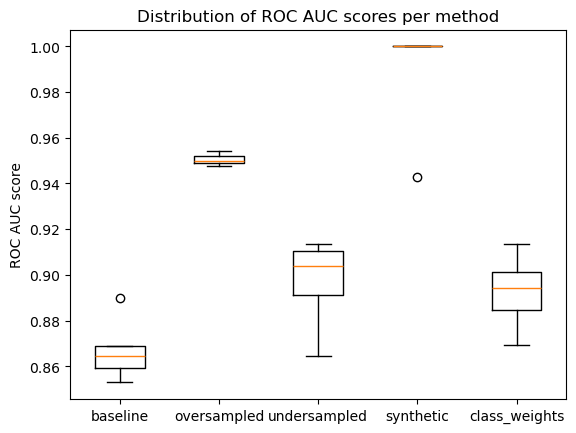

In [34]:
labels = ['baseline', 'oversampled', 'undersampled', 'synthetic', 'class_weights']
plt.boxplot(auc, tick_labels=labels)
plt.ylabel('ROC AUC score')
plt.title('Distribution of ROC AUC scores per method')
plt.show()

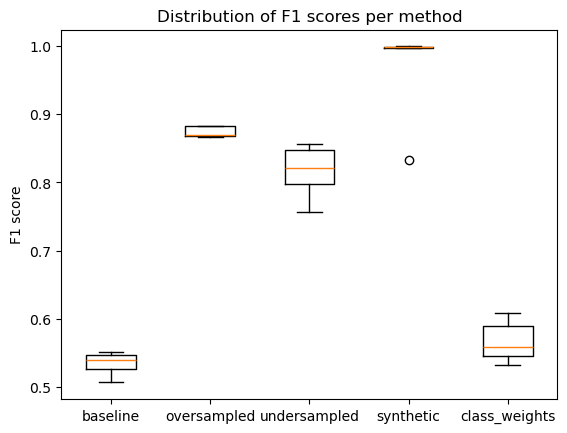

In [35]:
labels = ['baseline', 'oversampled', 'undersampled', 'synthetic', 'class_weights']
plt.boxplot(f1, tick_labels=labels)
plt.ylabel('F1 score')
plt.title('Distribution of F1 scores per method')
plt.show()

The clear winner is the synthetic data approach, yielding excellent results with minimal spread over the 5 runs. In second place comes the oversampling approach. Going into this experiment, I was expecting the class_weights approach to do much better, as this is the single technique that does not "manipulate", or modify, the data in any way. As it turns out, this was the worst method attempted. 